### Import tensorflow and relevant libraries

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as T
from torchvision import models
import os
import pandas as pd
from torchvision.io import read_image
from torch.utils.data import Dataset
from torchvision import datasets
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt
import time
import copy
from tqdm import tqdm

### Load the dataset

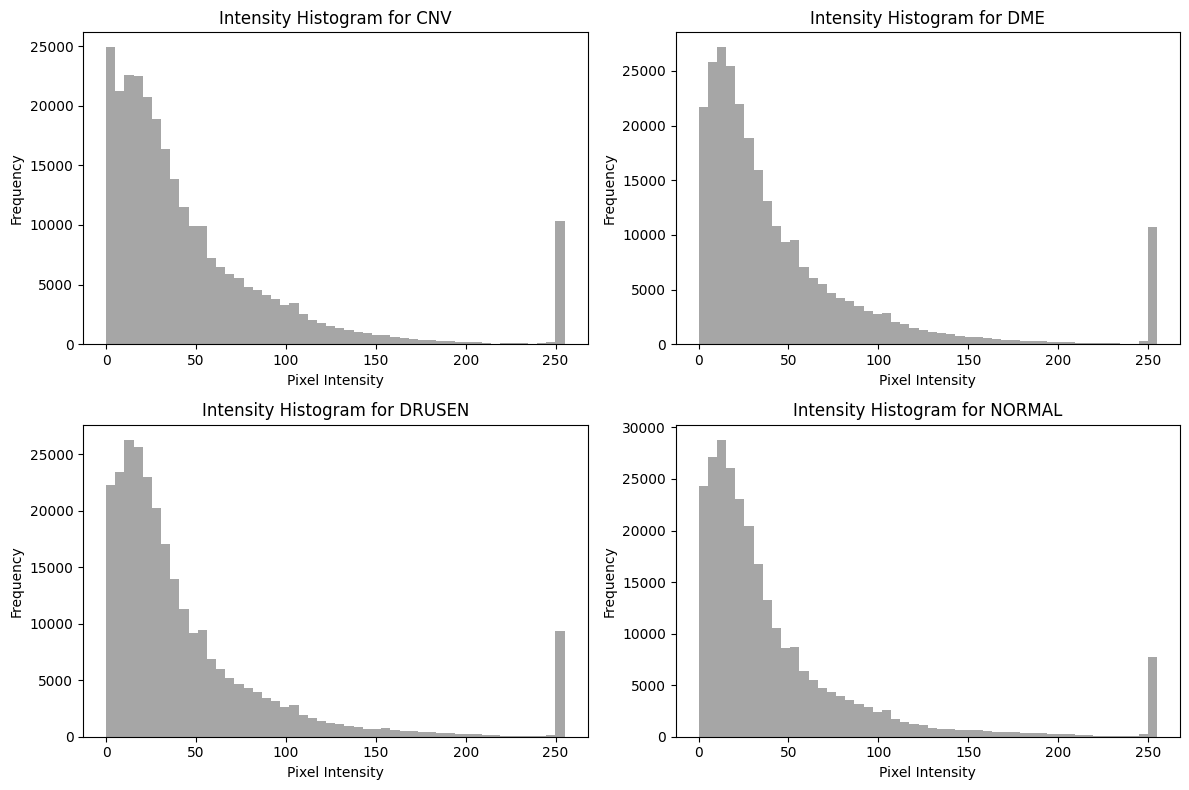

In [ ]:
base_path = base_path = r"C:\Users\sudee\Downloads\OCT2017\OCT2017"


class_names = ["CNV", "DME", "DRUSEN", "NORMAL"]



pixel_values_by_class = {class_name: [] for class_name in class_names}
images_per_class = 300


for class_name in class_names:
    class_folder = os.path.join(base_path, class_name)
    image_files = os.listdir(class_folder)[:images_per_class]
    for img_file in image_files:
        img_path = os.path.join(class_folder, img_file)
        image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        downscaled_image = cv2.resize(image, (30, 30)).ravel()
        pixel_values_by_class[class_name].extend(downscaled_image)


plt.figure(figsize=(12, 8))
for idx, class_name in enumerate(class_names):
    plt.subplot(2, 2, idx + 1)
    plt.hist(pixel_values_by_class[class_name], bins=50, color='gray', alpha=0.7)
    plt.title(f'Intensity Histogram for {class_name}')
    plt.xlabel('Pixel Intensity')
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()


class_names = ["CNV", "DME", "DRUSEN", "NORMAL"]



pixel_values_by_class = {class_name: [] for class_name in class_names}
images_per_class = 300


for class_name in class_names:
    class_folder = os.path.join(base_path, class_name)
    image_files = os.listdir(class_folder)[:images_per_class]
    for img_file in image_files:
        img_path = os.path.join(class_folder, img_file)
        image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        downscaled_image = cv2.resize(image, (30, 30)).ravel()
        pixel_values_by_class[class_name].extend(downscaled_image)


plt.figure(figsize=(12, 8))
for idx, class_name in enumerate(class_names):
    plt.subplot(2, 2, idx + 1)
    plt.hist(pixel_values_by_class[class_name], bins=50, color='gray', alpha=0.7)
    plt.title(f'Intensity Histogram for {class_name}')
    plt.xlabel('Pixel Intensity')
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

In [ ]:
# Load training dataset
train_path = r"C:\Users\sudee\Downloads\OCT2017\OCT2017\train"
train_data = CustomImageDataset(train_path)

# Load validation dataset
val_path = r"C:\Users\sudee\Downloads\OCT2017\OCT2017\val"
val_data = CustomImageDataset(val_path)

# Load test dataset
test_path = r"C:\Users\sudee\Downloads\OCT2017\OCT2017\test"
test_data = CustomImageDataset(test_path)

In [ ]:
from torch.utils.data import DataLoader

train_len = len(train_data)
train_dataloader = DataLoader(train_data, batch_size=64, shuffle=True)

val_len = len(val_data)
val_dataloader = DataLoader(val_data, batch_size=64, shuffle=True)

test_len = len(test_data)
test_dataloader = DataLoader(test_data, batch_size=8)

data_loaders = {'train':train_dataloader, 'val':val_dataloader}

Feature batch shape: torch.Size([64, 3, 224, 224])
Labels batch shape: torch.Size([64])


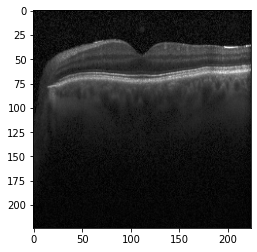

Label: 3


In [ ]:
train_features, train_labels = next(iter(train_dataloader))
print(f"Feature batch shape: {train_features.size()}")
print(f"Labels batch shape: {train_labels.size()}")
img = train_features[0].squeeze()
label = train_labels[0]
plt.imshow(img.permute(1, 2, 0))
plt.show()
print(f"Label: {label}")

In [ ]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
device

device(type='cuda', index=0)

## Create Training function

In [ ]:
def train_model(model, criterion, optimizer, num_epochs=3):
    since = time.time()

    best_acc = 0.0

    for epoch in range(num_epochs):
        print('Epoch {}/{}'.format(epoch + 1, num_epochs))
        print('-' * 10)
        for mode, data_loader in data_loaders.items():
            if mode == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_correct = 0

            # Iterate over batches
            for inputs, labels in tqdm(data_loader):
                inputs = inputs.to(device)
                labels = labels.to(device)

                with torch.set_grad_enabled(mode == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)
                    if mode == 'train':
                        optimizer.zero_grad()
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_correct += torch.sum(preds==labels.data)

            data_len = train_len

            if mode == 'val':
                data_len = val_len

            epoch_loss = running_loss / data_len
            epoch_acc = running_correct.double() / data_len

            print('{} loss: {:4f} acc: {:4f}'.format(mode, epoch_loss, epoch_acc))



## Defining model

In [ ]:
train_len, val_len, test_len

(83484, 32, 968)

In [ ]:
model = models.resnet18(pretrained=True)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 10)

model.to(device)
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=0.001)

Downloading: "https://download.pytorch.org/models/resnet18-5c106cde.pth" to /root/.cache/torch/hub/checkpoints/resnet18-5c106cde.pth


  0%|          | 0.00/44.7M [00:00<?, ?B/s]

In [ ]:
train_model(model, criterion, optimizer, num_epochs=10)

Epoch 1/10
----------


100%|██████████| 1305/1305 [16:47<00:00,  1.30it/s]


train loss: 0.197729 acc: 0.934407


100%|██████████| 1/1 [00:00<00:00,  3.23it/s]


val loss: 0.161058 acc: 0.906250
Epoch 2/10
----------


...

val loss: 0.014543 acc: 1.000000
Epoch 10/10
----------


100%|██████████| 1305/1305 [09:53<00:00,  2.20it/s]


train loss: 0.034859 acc: 0.987279


100%|██████████| 1/1 [00:00<00:00,  6.35it/s]

val loss: 0.002767 acc: 1.000000


In [ ]:
running_loss = 0.0
running_correct = 0

# Iterate over batches
for inputs, labels in tqdm(test_dataloader):
    inputs = inputs.to(device)
    labels = labels.to(device)

    with torch.set_grad_enabled(False):
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        loss = criterion(outputs, labels)

    running_loss += loss.item() * inputs.size(0)
    running_correct += torch.sum(preds==labels.data)

epoch_loss = running_loss / test_len
epoch_acc = running_correct.double() / test_len

print('{} loss: {:4f} acc: {:4f}'.format('test', epoch_loss, epoch_acc))

100%|██████████| 121/121 [00:09<00:00, 12.92it/s]

test loss: 0.012862 acc: 0.996901


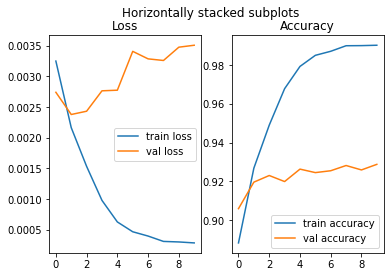

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2)
fig.suptitle('Horizontally stacked subplots')
ax1.plot(train_loss, label='train loss')
ax1.plot(val_loss, label = 'val loss')
ax1.legend()
ax1.set_title('Loss')
ax2.plot(train_acc, label = 'train accuracy')
ax2.plot(val_acc, label = 'val accuracy')
ax2.set_title('Accuracy')
ax2.legend()

Test Accuracy

In [ ]:
running_loss = 0.0
running_correct = 0
model.eval()
# Iterate over batches
for inputs, labels in tqdm(test_dataloader):
    inputs = inputs.to(device)
    labels = labels.to(device)

    with torch.set_grad_enabled(False):
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        loss = criterion(outputs, labels)

    running_loss += loss.item() * inputs.size(0)
    running_correct += torch.sum(preds==labels.data)

epoch_loss = running_loss / test_len
epoch_acc = running_correct.double() / test_len

print('{} loss: {:4f} acc: {:4f}'.format('test', epoch_loss, epoch_acc))

100%|██████████| 121/121 [00:12<00:00,  9.47it/s]

test loss: 0.101607 acc: 0.981405


<Figure size 432x288 with 0 Axes>

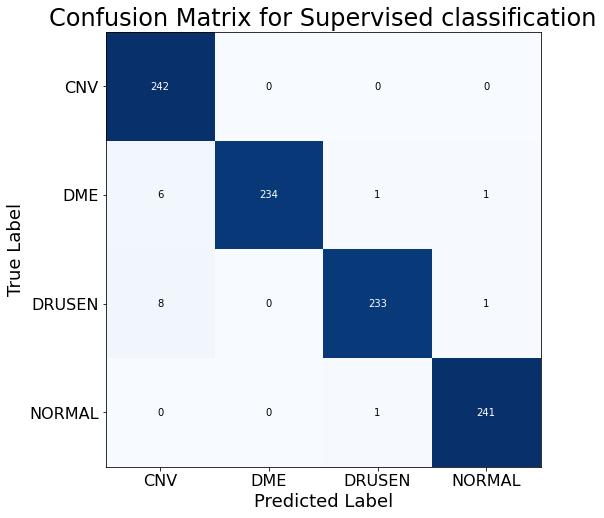

In [ ]:
cm_custom = plot_cm(labels, preds, classes, title='Confusion Matrix for Supervised classification')

In [ ]:
import torch
import torch.nn.functional as F
import numpy as np
from sklearn.metrics import confusion_matrix

def accuracy(outputs, labels):
    _, preds = torch.max(outputs, dim=1)
    return torch.tensor(torch.sum(preds == labels).item() / len(preds)), preds

def validation_step(batch, model):
    images, labels = batch
    images, labels = images.to(device), labels.to(device)
    out = model(images)
    loss = F.cross_entropy(out, labels)
    acc, preds = accuracy(out, labels)

    return {'val_loss': loss.detach(), 'val_acc': acc.detach(),
            'preds': preds.detach(), 'labels': labels.detach()}

def test_prediction(outputs):
    batch_losses = [x['val_loss'] for x in outputs]
    epoch_loss = torch.stack(batch_losses).mean()
    batch_accs = [x['val_acc'] for x in outputs]
    epoch_acc = torch.stack(batch_accs).mean()
    # combine predictions
    batch_preds = torch.cat([x['preds'] for x in outputs])
    # combine labels
    batch_labels = torch.cat([x['labels'] for x in outputs])

    return {'test_loss': epoch_loss.item(), 'test_acc': epoch_acc.item(),
            'test_preds': batch_preds.tolist(), 'test_labels': batch_labels.tolist()}

@torch.no_grad()
def test_predict(model, test_loader):
    model.eval()
    # perform testing for each batch
    outputs = [validation_step(batch, model) for batch in tqdm(test_loader)]
    results = test_prediction(outputs)
    print('test_loss: {:.4f}, test_acc: {:.4f}'
          .format(results['test_loss'], results['test_acc']))

    return results['test_preds'], results['test_labels']

# Plot confusion matrix
def plot_cm(labels, preds, classes, title=''):
    cm = confusion_matrix(labels, preds, labels=list(range(len(classes))))

    plt.figure()
    plot_confusion_matrix(cm, figsize=(12, 8), cmap=plt.cm.Blues)
    plt.xticks(range(len(classes)), classes, fontsize=16)
    plt.yticks(range(len(classes)), classes, fontsize=16)
    plt.xlabel('Predicted Label', fontsize=18)
    plt.ylabel('True Label', fontsize=18)
    plt.title(title, fontsize=24)
    plt.show()

    return cm

def calculate_metrics(cm, preds, labels, classes):
    # Compute Performance Metrics
    accuracy = (np.array(preds) == np.array(labels)).sum() / len(preds)
    precision = np.diag(cm) / cm.sum(axis=0)
    recall = np.diag(cm) / cm.sum(axis=1)
    f1 = 2 * (precision * recall) / (precision + recall)

    print("Accuracy of the model is {:.2f}".format(accuracy))
    for i, class_name in enumerate(classes):
        print("Precision of {} class is {:.2f}".format(class_name, precision[i]))
        print("Recall of {} class is {:.2f}".format(class_name, recall[i]))
        print("F1 Score of {} class is {:.2f}".format(class_name, f1[i]))


In [ ]:
preds, labels = test_predict(model, test_dataloader)

100%|██████████| 121/121 [00:06<00:00, 18.16it/s]

test_loss: 0.1016, test_acc: 0.9814
